In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
data = np.random.rand(10, 12)
sns.heatmap(data, annot=True, fmt=".2f", cmap='viridis')
plt.title('Heatmap')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.show()
# Output: A 10x12 heatmap with annotated values

In [ ]:
import numpy as np
from matplotlib.pylab import plt
import seaborn as sns

data = np.random.randn(1000)
sns.histplot(data, bins=30, kde=True)
plt.title('Histogram with KDE')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
import pandas as pd

path = "D:/New_Download/titanic.csv"
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
df = pd.read_csv(url)
# print(df.info())
# print(df.describe())
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print(df.info())

In [ ]:
import sympy as sp
x = sp.symbols('x')
expr = sp.sin(x) * sp.exp(x)
derivative = sp.diff(expr, x)
print(derivative)  # Output: Derivative of the expression

In [ ]:
### stochastic gradient descent
import numpy as np

np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Add bias term (intercept) to X
X_b = np.c_[np.ones((100, 1)), X]

# SGD Implementation
def stochastic_gradient_descent(X, y, learning_rate=0.01, n_epochs=1000):
    m = len(y)
    theta = np.random.randn(2, 1)  # Random initialization of parameters

    for epoch in range(n_epochs):
        for i in range(m):
            random_index = np.random.randint(m)
            xi = X[random_index:random_index+1]
            yi = y[random_index:random_index+1]
            gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
            theta -= learning_rate * gradients
    return theta

theta_sgd = stochastic_gradient_descent(X_b, y)
print("Parameters from SGD:\n", theta_sgd)  # Output: Estimated parameters from SGD

In [ ]:
# Plotting a simple binomial distribution
import matplotlib.pyplot as plt
from scipy.stats import binom

n, p = 10, 0.5
x = np.arange(0, n+1)
y = binom.pmf(x, n, p)
plt.bar(x, y, color="skyblue", alpha=1)
plt.title('Binomial Distribution PMF')
plt.xlabel('Number of Successes')
plt.ylabel('Probability')
plt.show()

In [ ]:
# Plotting a simple Poisson distribution
from matplotlib.pylab import plt
from scipy.stats import poisson
import numpy as np

lam = 3.0
x = np.arange(0, 10)
y = poisson.pmf(x, lam)
plt.bar(x, y, color="lightgreen", alpha=0.7)
plt.title('Poisson Distribution PMF')
plt.xlabel('Number of Events')
plt.ylabel('Probability')
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split  # 数据拆分工具
from sklearn.linear_model import LinearRegression     # 线性回归模型
from sklearn.metrics import mean_squared_error, r2_score  # 模型评估指标
from matplotlib import pyplot as plt

# 生成模拟数据（模拟 y = 3x + 2 + 随机噪声）
np.random.seed(128)  # 固定随机种子，保证结果可复现
X = np.random.rand(100, 1) * 100  # 生成100个[0,100)的随机数（特征X）
y = 4 + 3 * X + np.random.rand(100, 1)   # 构造y：真实斜率3、截距4，加小噪声

# 拆分训练集/测试集（测试集占20%）
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

model = LinearRegression()  # 初始化线性回归模型
model.fit(X_train, y_train)  # 用训练集训练模型

# 用测试集做预测
y_pred = model.predict(X_test)

# 输出模型学到的“斜率”和“截距”
print("Slope : ", model.coef_[0][0])  # 对应y=kx+b中的k
print("Intercept : ", model.intercept_[0])  # 对应y=kx+b中的b

plt.scatter(X_test, y_test, color="blue", label="Actual")  # 测试集真实值（蓝色散点）
plt.plot(X_test, y_pred, color="red", label="Predicted")   # 模型预测值（红色直线）
plt.title("Linear Regression Model")  # 图表标题
plt.xlabel("X")  # X轴标签
plt.ylabel("y")  # Y轴标签
plt.legend()     # 显示图例
plt.show()       # 展示图表

mse = mean_squared_error(y_test, y_pred)  # 均方误差（衡量预测误差，越小越好）
r2 = r2_score(y_test, y_pred)             # R²分数（衡量拟合程度，越接近1越好）

print("Mean Squared Error:", mse)
print("R² Score:", r2)  

In [ ]:
# Polynomial Regression Example

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 1 + 3 * X**2 + np.random.randn(100, 1)

# Transform features to polynomial features
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Fit Polynomial Regression model
model = LinearRegression()
model.fit(X_poly, y)

# Predict using the model
y_pred = model.predict(X_poly)

# Plot the results
plt.scatter(X, y, color='blue', label='Actual')
plt.scatter(X, y_pred, color='red', label='Predicted')
plt.title('Polynomial Regression (Degree 2)')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

print("Mean Squared Error:", mean_squared_error(y, y_pred))
print("R² Score:", r2_score(y, y_pred))


In [ ]:
# Regularization with Ridge and Lasso Regression

import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split

# Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1)
y = 1 + 3 * X**2 + np.random.randn(100, 1)

# Transform features to polynomial features
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Fit Ridge Regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_ridge_pred = ridge_model.predict(X_test)

# Fit Lasso Regression model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
y_lasso_pred = lasso_model.predict(X_test)

# Elevate Ridge and Lasso predictions for better visualization
ridge_mse = mean_squared_error(y_test, y_ridge_pred)

lasso_mse = mean_squared_error(y_test, y_lasso_pred)
print("Ridge Mean Squared Error:", ridge_mse)
print("Lasso Mean Squared Error:", lasso_mse)



In [ ]:
# logistic regression example
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Generate synthetic binary classification data
np.random.seed(42)
X = np.random.rand(100, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)  # Simple decision boundary

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Fit Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)
# Predict using the model
y_pred = model.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred) # Calculate accuracy
precision = precision_score(y_test, y_pred) # Calculate precision
recall = recall_score(y_test, y_pred) # Calculate recall
f1_score = f1_score(y_test, y_pred) # Calculate F1 score
class_report = classification_report(y_test, y_pred) # Generate classification report

x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01)) # Create a grid of points
Z = model.predict(np.c_[xx.ravel(), yy.ravel()]) # Predict class labels for each point in the grid
Z = Z.reshape(xx.shape) # Reshape the predictions to match the grid shape
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu) # Plot decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)
print("\nClassification Report:\n", class_report)

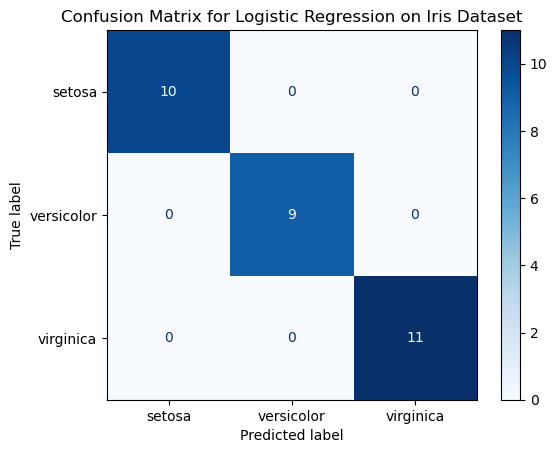

In [ ]:
# COnfusion Matrix for Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)
# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression on Iris Dataset')
plt.show()



In [ ]:
### KNN vs Logistic Regression on Iris Dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

# Load Iris dataset
data = load_iris()
# Split the dataset into features and target variable
X, y = data.data, data.target
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()   # normalize features
X_train = scaler.fit_transform(X_train)     # fit and transform training data
X_test = scaler.transform(X_test)   # transform testing data

# Train logistic regression model
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

# Predict using logistic regression
y_log_reg_pred = log_reg.predict(X_test)
# Evaluate logistic regression model
log_reg_accuracy = accuracy_score(y_test, y_log_reg_pred)
print("Logistic Regression Accuracy:", log_reg_accuracy)

# Evaluate KNN
best_k = 5
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, y_knn_pred)
print("KNN Accuracy with k={}: {}".format(best_k, knn_accuracy)) 

# Detailed Comparison of Logistic Regression and KNN
print("\nLogistic Regression Classification Report:\n", classification_report(y_test, y_log_reg_pred))

print(classification_report(y_test, y_log_reg_pred))
print("\nKNN Classification Report:\n", classification_report(y_test, y_knn_pred))


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



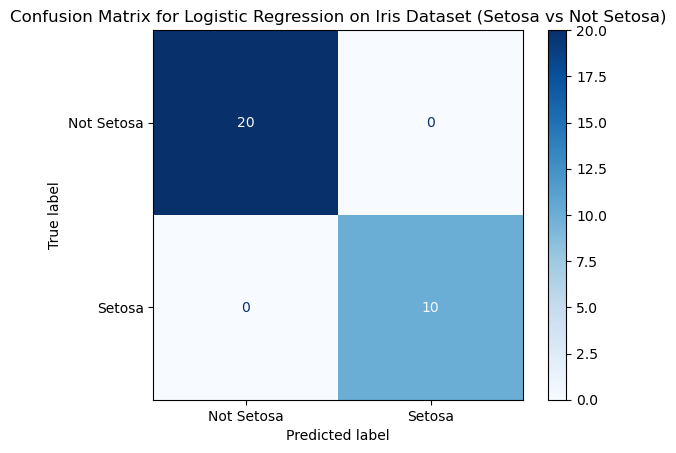

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt


# Load the Iris dataset
data_iris = load_iris()
X = data_iris.data
y = (data_iris.target == 0).astype(int)  # Binary classification: Iris-Setosa vs. Not Iris-Setosa

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression model   
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Generate classification report
print("Classification Report:\n", classification_report(y_test, y_pred))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Setosa', 'Setosa'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Logistic Regression on Iris Dataset (Setosa vs Not Setosa)')
plt.show()



In [ ]:
# Linear Regression on California Housing Dataset

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split    
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score #  model metrics

# Load California Housing dataset
data_house = fetch_california_housing()
X, y = data_house.data, data_house.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)  # Mean Absolute Error
mse = mean_squared_error(y_test, y_pred)  # Mean Squared Error
r2 = r2_score(y_test, y_pred)  # R-squared Score

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("R² Score:", r2)


In [16]:
# Corss-validation example
import pandas as pd
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


# Loading Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv"
df = pd.read_csv(url)

# print(df.info())
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Survived']]

# Handle missing values
# df['Age'].fillna(df['Age'].median(), inplace=True)
# df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.fillna({'Age': df['Age'].median(), 'Embarked': df['Embarked'].mode()[0]}, inplace=True)

# Define feature columns and target variable
X = df.drop(columns=['Survived'])   # Features
y = df['Survived']

# Preprocessing: Scaling numerical features and encoding categorical features
numerical_features = ['Age', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])  
X_processed = preprocessor.fit_transform(X)

# Train Logistic Regression model
log_reg = LogisticRegression(max_iter=200)
log_scores = cross_val_score(log_reg, X_processed, y, cv=5, scoring='accuracy')
# print("Logistic Regression Cross-Validation Accuracy Scores:", log_scores)
# print("Logistic Regression Average CV Accuracy:", log_scores.mean())

# Train Random Forest Classifier model
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_scores = cross_val_score(rf_clf, X_processed, y, cv=5, scoring='accuracy')
# print("Random Forest Classifier Cross-Validation Accuracy Scores:", rf_scores)

# Define hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Perfrom grid search with cross-validation
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_clf, 
    param_grid=param_grid, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)
grid_search.fit(X_processed, y)

# Output best hyperparameters and corresponding accuracy
print("Best Hyperparameters for Random Forest:", grid_search.best_params_)
print("Best Cross-Validation Accuracy for Random Forest:", grid_search.best_score_)


Best Hyperparameters for Random Forest: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best Cross-Validation Accuracy for Random Forest: 0.8339087314041805


In [ ]:
# Ensemble Learning with Voting Classifier on Iris Dataset
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train, y_train)
    accuracy = model.score(X_test, y_test)
    print(f"{model_name} Accuracy: {accuracy:.4f}")

# Creating Voting Classifier

voting_clf = VotingClassifier(
    estimators=[
        ('log_reg', models['Logistic Regression']),
        ('dec_tree', models['Decision Tree']),
        ('knn', models['K-Nearest Neighbors'])
    ],
    voting='hard'  # Use 'soft' for probability-based voting
)

# Train ensemble model
voting_clf.fit(X_train, y_train)

# Predict using ensemble model
y_voting_pred = voting_clf.predict(X_test)

# Evaluate ensemble model
voting_accuracy = voting_clf.score(X_test, y_test)
print(f"Voting Classifier Accuracy: {voting_accuracy:.4f}")



In [ ]:
# Linear, Ridge, and Lasso Regression on California Housing Dataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target
feature_names = housing.feature_names

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train linear regression model
model = LinearRegression()
model.fit(X_train, y_train)
# Predict using the model
y_pred = model.predict(X_test)
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)

# Train Ridge regression model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
# Predict using Ridge model
y_ridge_pred = ridge_model.predict(X_test)
# Evaluate Ridge model
ridge_mse = mean_squared_error(y_test, y_ridge_pred)
print("Ridge Mean Squared Error:", ridge_mse)
print("Feature Coefficients from Linear Regression:", ridge_model.coef_)

# Train Lasso regression model
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)
# Predict using Lasso model
y_lasso_pred = lasso_model.predict(X_test)
# Evaluate Lasso model
lasso_mse = mean_squared_error(y_test, y_lasso_pred)
print("Lasso Mean Squared Error:", lasso_mse)
print("Feature Coefficients from Lasso Regression:", lasso_model.coef_)


Mean Absolute Error: 0.5332001304956989
Mean Squared Error: 0.5558915986952424
Ridge Mean Squared Error: 0.5558034669932191
Feature Coefficients from Linear Regression: [ 4.48510924e-01  9.72596535e-03 -1.23014157e-01  7.81416761e-01
 -2.02581346e-06 -3.52585878e-03 -4.19786908e-01 -4.33680793e-01]
Lasso Mean Squared Error: 0.6135115198058131
Feature Coefficients from Lasso Regression: [ 3.92693362e-01  1.50810624e-02 -0.00000000e+00  0.00000000e+00
  1.64168387e-05 -3.14918929e-03 -1.14291203e-01 -9.93076483e-02]


In [12]:
# "D:\New_Download\Telco_customer_churn.xlsx"
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np


path = "D:/New_Download/Telco_customer_churn.xlsx"
df = pd.read_excel(path)
# print(df.head())

# Handle missing values
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df.fillna({'Total Charges': df['Total Charges'].median()}, inplace=True)

# Encode categorical variables
label_encoders = LabelEncoder()
for column in df.select_dtypes(include=['object']).columns:
    if column != 'Churn Value':
        df[column] = label_encoders.fit_transform(df[column])

# Encode target variable
df['Churn Value'] = label_encoders.fit_transform(df['Churn Value'])

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['Tenure Months', 'Monthly Charges', 'Total Charges']
df[numerical_features] = scaler.fit_transform(df[numerical_features])

# Feature-target split
X = df.drop(columns=['Churn Value'])
y = df['Churn Value']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
print("Random Forest Classifier Accuracy on Telco Customer Churn Dataset:", accuracy)
print("Classification Report:\n", classification_rep)


# Define parameter grid for Randomized Search
param_grid = {
    'n_estimators': np.arange(50, 301, 50),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# Initialize Randomized Search with Cross-Validation
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
# Get best hyperparameters and corresponding accuracy
print("Best Hyperparameters from Randomized Search:", random_search.best_params_) 

# Train best model from Randomized Search
best_model = random_search.best_estimator_
# Predict using the best model
y_best_pred = best_model.predict(X_test)
# Evaluate the best model
best_accuracy = accuracy_score(y_test, y_best_pred)
best_classification_rep = classification_report(y_test, y_best_pred)
print("Best Model Accuracy on Telco Customer Churn Dataset:", best_accuracy)
print("Best Model Classification Report:\n", best_classification_rep)


# Evaluate using cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", cv_scores)
print("Average Cross-Validation Accuracy:", cv_scores.mean())


Random Forest Classifier Accuracy on Telco Customer Churn Dataset: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

Best Hyperparameters from Randomized Search: {'n_estimators': np.int64(200), 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 30}
Best Model Accuracy on Telco Customer Churn Dataset: 1.0
Best Model Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1009
           1       1.00      1.00      1.00       400

    accuracy                           1.00      1409
   macro avg       1.00      1.00      1.00      1409
weighted avg       1.00      1.00      1.00      1409

Cross-Validation A